# Earthquake Phenomonology


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# set font
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams.update({'font.size': 16})

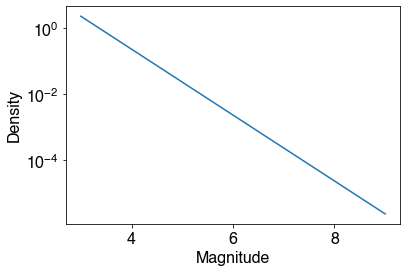

In [5]:
## Unbounded G-R law

b   = 1.0    # b-value [-]
omg = 9      # max expected magnitude [-] (ad hoc bounded at here)
m0  = 3      # cutoff magnitude [-]

# b-value in log
beta = b * np.log(10)

# magnitude range from m0 to omg
ms = np.linspace(m0, omg, 100)

# G-R law density
f = beta*np.exp(-beta*ms) / (np.exp(-beta*m0) - np.exp(-beta*omg))

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(ms, f)
ax.set_yscale('log')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Density')
plt.show()

n0-nc =  -0.06569582757210146


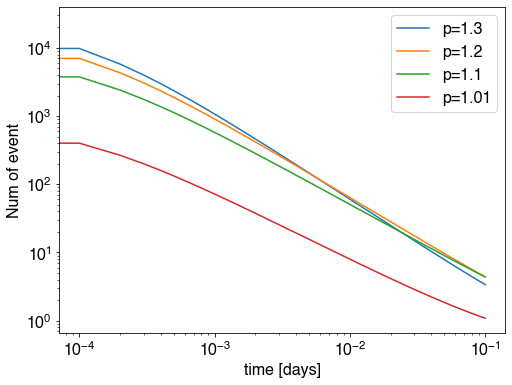

In [74]:
## The Temporal ETAS model (Ogata, 1988)
## use params in Marsan 2017, the study in Japan trench

m0=3
alpha=2
#p=1.1
p = np.array([1.3, 1.2, 1.1, 1.01])
c=10e-5 # [days]
b=0.95
beta=b*np.log(10)
mu=0.33 # [per day]
mi = 6
ts = np.linspace(0, 0.1, 1000)
ti=0
n0=0.02
print('n0-nc = ', n0-1+alpha/beta)


# total rate
#rate = mu + n0 * np.exp(alpha*(mi-m0)) * (p-1)/c * (1+(ts-ti)/c)**-p
rate = []
for i, pi in enumerate(p):
    rate_i = mu + n0 * np.exp(alpha*(mi-m0)) * (pi-1)/c * (1+(ts-ti)/c)**-pi
    rate.append(rate_i)


fig = plt.figure(figsize=[8,6])
ax = fig.add_subplot(1, 1, 1)
#ax.plot(ts, rate, label='p={}'.format(p))
for i, (pi, rate_i) in enumerate(zip(p,rate)):
    ax.plot(ts, rate_i, label='p={}'.format(pi))
ax.set_xlabel('time [days]')
ax.set_ylabel('Num of event')
ax.set_xscale('log')
ax.set_yscale('log')
plt.legend()
plt.show()

In [75]:

n0 = 0.024
alpha = 0.5
b = 1.0
beta = b * np.log(10)
print(n0-1+alpha/beta)



-0.7588527590483741


In [ ]:
mu = 2.15   # background rate [num/day]
k0 = 1      # productivity of an event of threshold magnitude m0 [-]
alpha = 2   # efficiency of a shock of generating aftershocks relative to its magnitude [mag^-1]
c  = 2      # decay latent time in Omori-Utsu law [days]
p = np.array([1.3, 1.1, 1.0, 0.9, 0.5, 0.2])     # decay exponent in Omori-Utsu law [-]
add_term = (p-1)*c**(p-1)       

# time axis [days]
ts = np.linspace(0, 100, 1000)

# given a single mainshock
mi = 6.0
ti = 0

# total rate
lamb = []
for i, (pi, add_i) in enumerate(zip(p, add_term)):
    lamb_i = mu + k0*(np.exp(alpha*(mi-m0))/(ts-ti+c)**pi)*add_i
    lamb.append(lamb_i)


fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
for i, (pi, lamb_i) in enumerate(zip(p,lamb)):
    ax.plot(ts, lamb_i, label='p={}'.format(pi))
ax.set_xlabel('time [days]')
ax.set_ylabel('Num of event')
plt.legend()
plt.show()

<ipython-input-18-cc8ce61ec115>:16: RuntimeWarning: invalid value encountered in log10
  N = np.log10(M0_rate/(10**(alpha-b*ms)-1)) - beta - np.log10(b) - np.log10(3) - b*ms


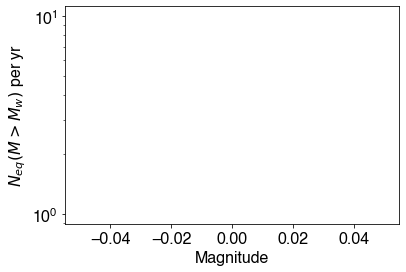

In [18]:
## Moment deficit rate conservation

alpha   = 3/2         # alpha
beta    = 9           # beta 
b       = 1.0         # b-value [-]
L       = 300e3       # length of fault [m]
W       = 12e3        # width of fault [m]
rigid   = 33e9        # Pascal [N/m**2]
u       = 5           # fault geodetic slip rate [cm/yr]
u       = u * 1e-2/(365.25*24*60*60)      # convert to [m/s]

# moment deficit rate
M0_rate = rigid * L * W * u       # [N*m/s]

# N: the frequency of the maximum eq that is needed for each magnitude to balance the moment buildup
N = np.log10(M0_rate/(10**(alpha-b*ms)-1)) - beta - np.log10(b) - np.log10(3) - b*ms

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(ms, N)
ax.set_yscale('log')
ax.set_xlabel('Magnitude')
ax.set_ylabel(r'$N_{eq}(M>M_w)$ per yr')
plt.show()

In [19]:
M0_rate

188227241615.33197

In [23]:
np.log10(M0_rate/(10**(alpha-b*ms)-1))

<ipython-input-23-4adf8c063907>:1: RuntimeWarning: invalid value encountered in log10
  np.log10(M0_rate/(10**(alpha-b*ms)-1))


array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [24]:
M0_rate/(10**(alpha-b*ms)-1)

array([-1.94373884e+11, -1.93550635e+11, -1.92840264e+11, -1.92226647e+11,
       -1.91696120e+11, -1.91237070e+11, -1.90839596e+11, -1.90495235e+11,
       -1.90196735e+11, -1.89937875e+11, -1.89713304e+11, -1.89518416e+11,
       -1.89349236e+11, -1.89202338e+11, -1.89074759e+11, -1.88963937e+11,
       -1.88867655e+11, -1.88783994e+11, -1.88711290e+11, -1.88648101e+11,
       -1.88593177e+11, -1.88545433e+11, -1.88503928e+11, -1.88467843e+11,
       -1.88436469e+11, -1.88409191e+11, -1.88385472e+11, -1.88364847e+11,
       -1.88346913e+11, -1.88331317e+11, -1.88317754e+11, -1.88305960e+11,
       -1.88295703e+11, -1.88286783e+11, -1.88279026e+11, -1.88272279e+11,
       -1.88266412e+11, -1.88261309e+11, -1.88256871e+11, -1.88253011e+11,
       -1.88249654e+11, -1.88246735e+11, -1.88244195e+11, -1.88241987e+11,
       -1.88240066e+11, -1.88238396e+11, -1.88236943e+11, -1.88235679e+11,
       -1.88234580e+11, -1.88233624e+11, -1.88232793e+11, -1.88232070e+11,
       -1.88231441e+11, -

In [26]:
10**(alpha-b*ms)

array([3.16227766e-02, 2.75038784e-02, 2.39214708e-02, 2.08056754e-02,
       1.80957154e-02, 1.57387304e-02, 1.36887451e-02, 1.19057724e-02,
       1.03550337e-02, 9.00628020e-03, 7.83320322e-03, 6.81292069e-03,
       5.92553098e-03, 5.15372466e-03, 4.48244688e-03, 3.89860370e-03,
       3.39080668e-03, 2.94915073e-03, 2.56502091e-03, 2.23092437e-03,
       1.94034425e-03, 1.68761248e-03, 1.46779927e-03, 1.27661695e-03,
       1.11033632e-03, 9.65713905e-04, 8.39928706e-04, 7.30527154e-04,
       6.35375264e-04, 5.52617002e-04, 4.80638086e-04, 4.18034496e-04,
       3.63585086e-04, 3.16227766e-04, 2.75038784e-04, 2.39214708e-04,
       2.08056754e-04, 1.80957154e-04, 1.57387304e-04, 1.36887451e-04,
       1.19057724e-04, 1.03550337e-04, 9.00628020e-05, 7.83320322e-05,
       6.81292069e-05, 5.92553098e-05, 5.15372466e-05, 4.48244688e-05,
       3.89860370e-05, 3.39080668e-05, 2.94915073e-05, 2.56502091e-05,
       2.23092437e-05, 1.94034425e-05, 1.68761248e-05, 1.46779927e-05,
      

In [ ]:
## 
ll = 1
k=3
p = ll**k * np.exp(-ll)/(3*2*1)
